Обработка: 100%|██████████| 1071/1071 [00:22<00:00, 47.92it/s]



Группа 1: 3 дубликатов


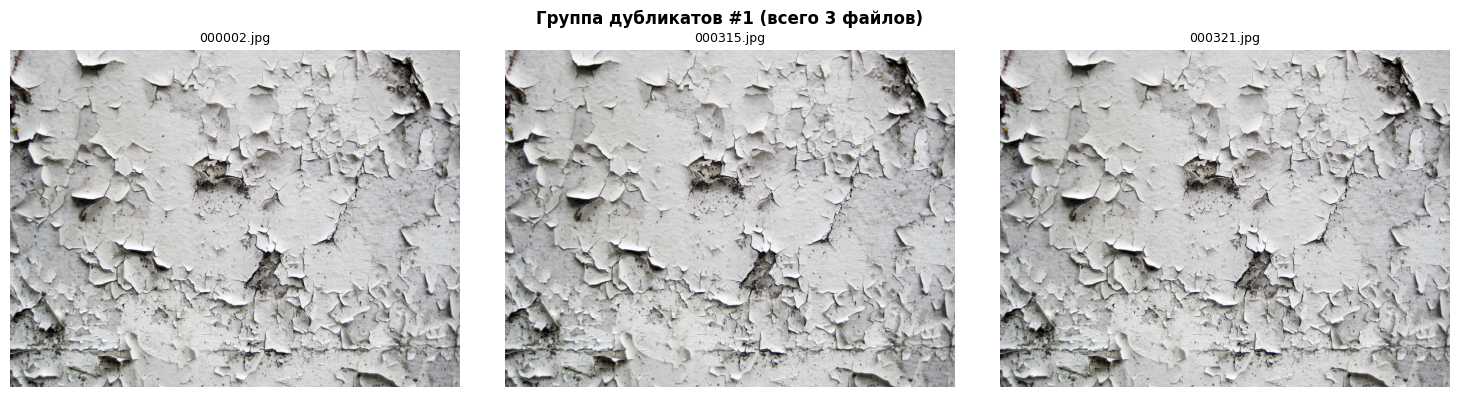


Группа 2: 3 дубликатов


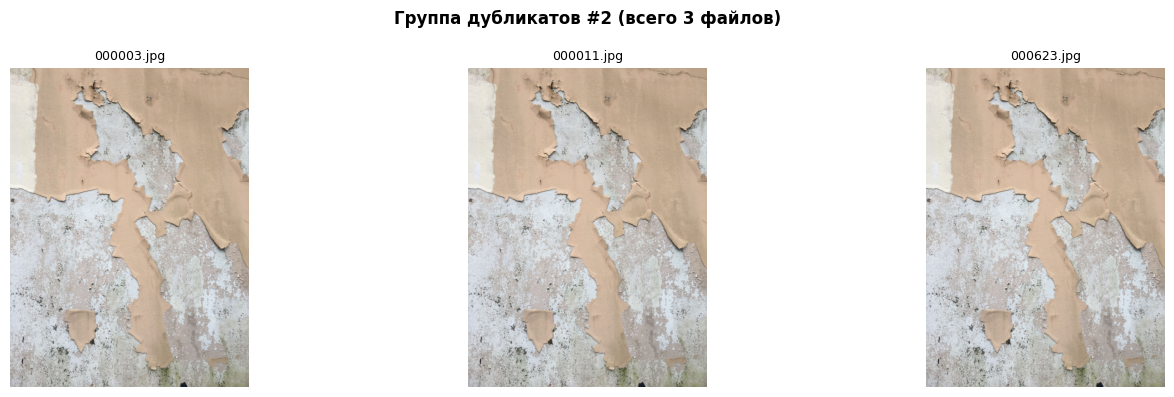


Группа 3: 6 дубликатов


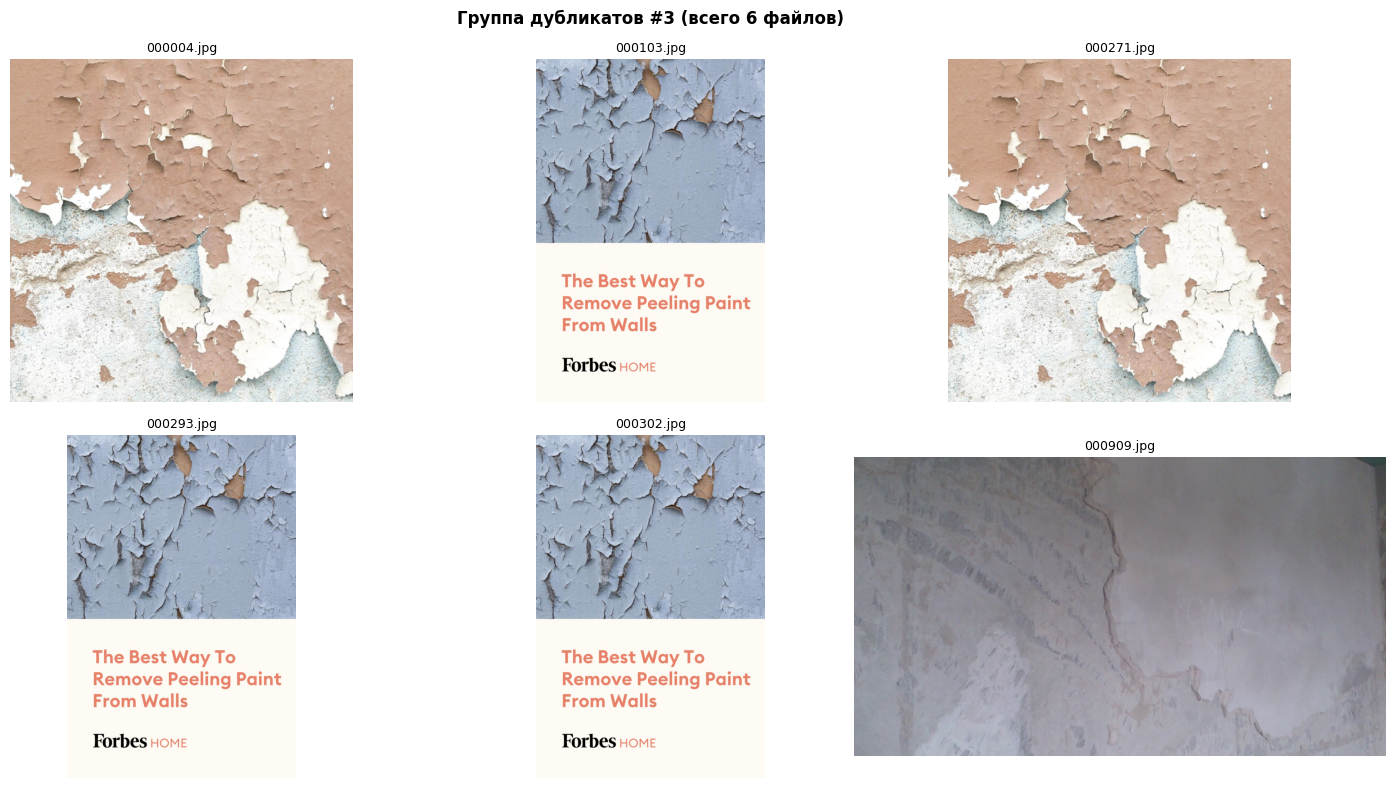


Скопировано файлов: 609, ошибок: 0

ИТОГОВАЯ СТАТИСТИКА:
   Исходных изображений: 1071
   Удалено дубликатов: 462
   Осталось: 609

Очищенная копия: C:/datasets/hesh


Обработка: 100%|██████████| 1071/1071 [00:15<00:00, 69.30it/s]



Группа 1: 3 дубликатов


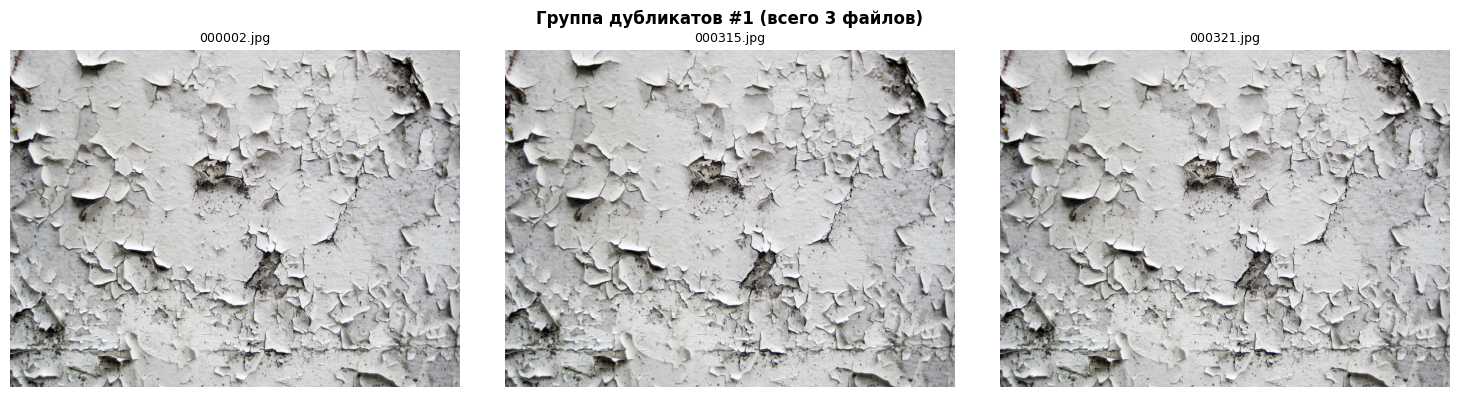


Группа 2: 3 дубликатов


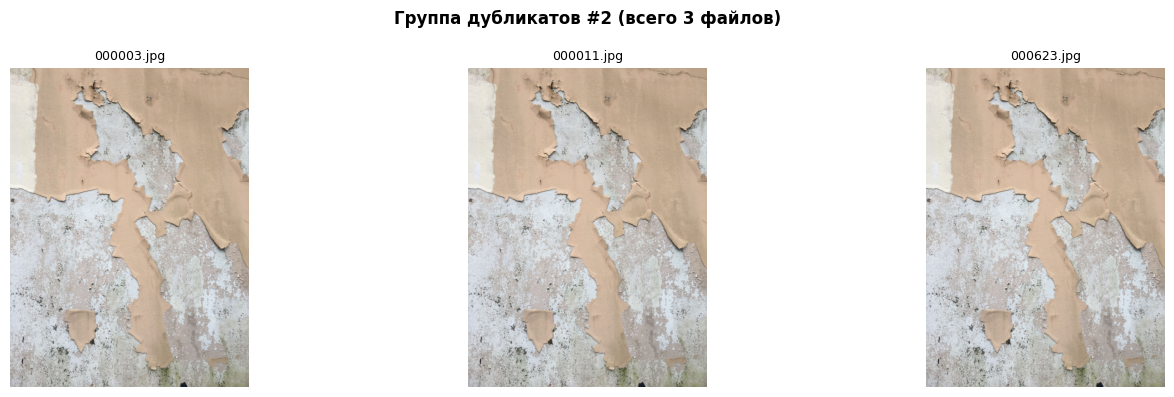


Группа 3: 6 дубликатов


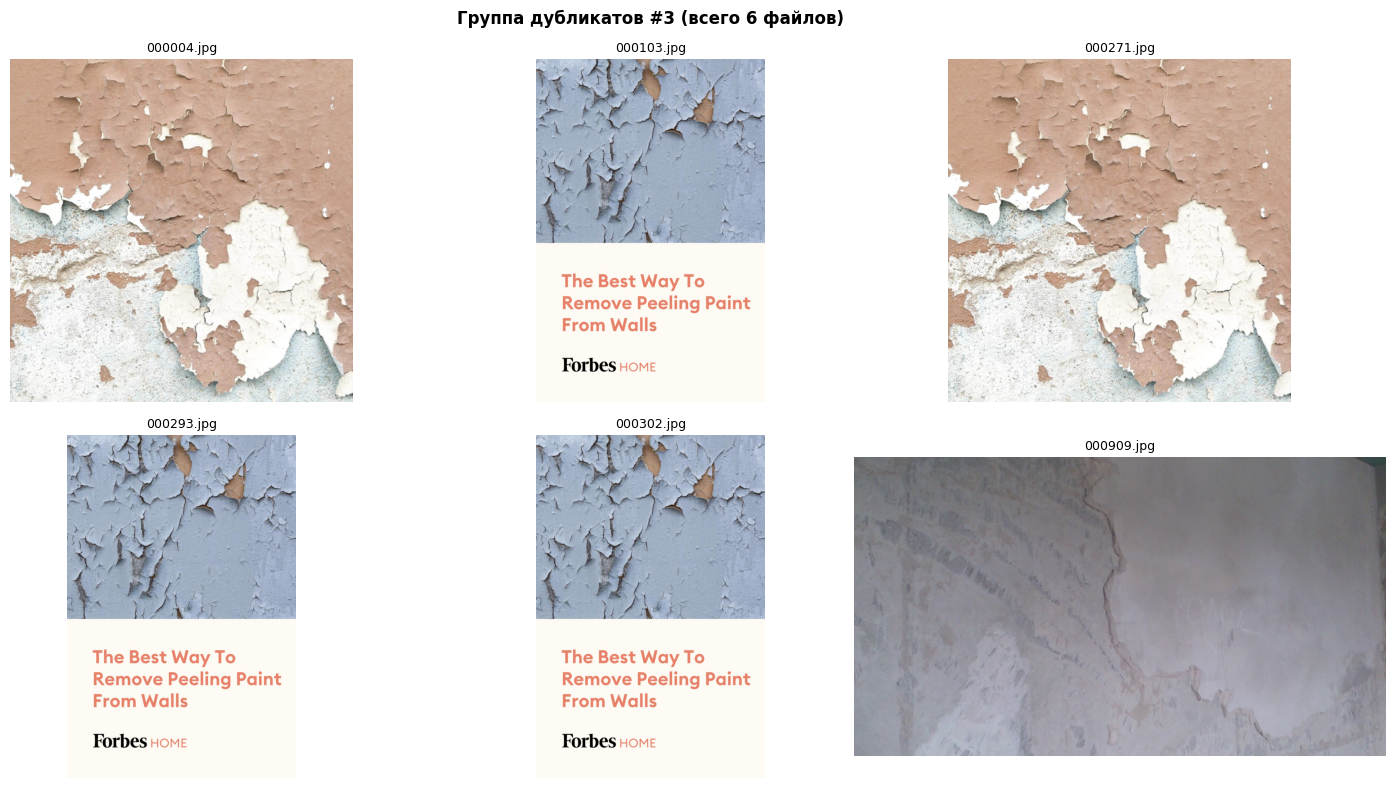


Скопировано файлов: 609, ошибок: 0

ИТОГОВАЯ СТАТИСТИКА:
   Исходных изображений: 1071
   Удалено дубликатов: 462
   Осталось: 609

Очищенная копия: C:/datasets/hesh


In [1]:
import os
import shutil
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

def calculate_image_hash_pil(image_path, hash_size=8):
    try:
        with Image.open(image_path) as img:
            if img.mode != 'L':
                img = img.convert('L')
            img_resized = img.resize((hash_size, hash_size), Image.Resampling.LANCZOS)
            pixels = np.array(img_resized)
            avg = pixels.mean()
            hash_img = (pixels > avg).astype(int)
            return ''.join(str(bit) for row in hash_img for bit in row)
    except Exception:
        return None

def hamming_distance(hash1, hash2):
    return sum(c1 != c2 for c1, c2 in zip(hash1, hash2))

def collect_all_images(root_folder, extensions=None):
    if extensions is None:
        extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp', 
                      '.JPG', '.JPEG', '.PNG', '.BMP', '.TIFF', '.TIF', '.WEBP'}
    image_paths = []
    for root, dirs, files in os.walk(root_folder):
        for file in files:
            if os.path.splitext(file)[1] in extensions:
                image_paths.append(os.path.join(root, file))
    return image_paths

def find_duplicates(image_paths, threshold=8):
    hash_to_path = {}
    duplicate_groups = defaultdict(list)
    
    for path in tqdm(image_paths, desc="Обработка"):
        img_hash = calculate_image_hash_pil(path)
        if img_hash is None:
            continue
        
        found = False
        for existing_hash in list(hash_to_path.keys()):
            if hamming_distance(img_hash, existing_hash) <= threshold:
                duplicate_groups[existing_hash].append(path)
                found = True
                break
        
        if not found:
            hash_to_path[img_hash] = path
            duplicate_groups[img_hash].append(path)
    
    return {h: paths for h, paths in duplicate_groups.items() if len(paths) > 1}

def visualize_duplicates(duplicate_groups, max_groups=5):
    if not duplicate_groups:
        return
    
    for i, (hash_val, paths) in enumerate(list(duplicate_groups.items())[:max_groups]):
        print(f"\nГруппа {i+1}: {len(paths)} дубликатов")
        
        images = []
        valid_paths = []
        for path in paths[:6]:
            try:
                with Image.open(path) as img:
                    img_rgb = img.convert('RGB')
                    images.append(np.array(img_rgb))
                    valid_paths.append(path)
            except:
                continue
        
        if not images:
            continue
        
        cols = min(3, len(images))
        rows = (len(images) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
        if len(images) == 1:
            axes = [axes]
        axes = axes.flatten() if rows * cols > 1 else [axes]
        
        for j, (ax, img, path) in enumerate(zip(axes, images, valid_paths)):
            ax.imshow(img)
            filename = os.path.basename(path)
            if len(filename) > 30:
                filename = filename[:27] + "..."
            ax.set_title(f"{filename}", fontsize=9)
            ax.axis('off')
        
        for j in range(len(images), len(axes)):
            axes[j].axis('off')
        
        plt.suptitle(f"Группа дубликатов #{i+1} (всего {len(paths)} файлов)", fontweight='bold')
        plt.tight_layout()
        plt.show()

def create_clean_copy(source_root, dest_root, duplicate_groups):
    if os.path.exists(dest_root):
        shutil.rmtree(dest_root)
    
    files_to_skip = set()
    for paths in duplicate_groups.values():
        files_to_skip.update(paths[1:])
    
    copied = 0
    errors = 0
    
    for root, dirs, files in os.walk(source_root):
        rel_path = os.path.relpath(root, source_root)
        dest_dir = dest_root if rel_path == '.' else os.path.join(dest_root, rel_path)
        
        try:
            os.makedirs(dest_dir, exist_ok=True)
        except Exception as e:
            print(f"Ошибка создания папки: {e}")
            continue
        
        for file in files:
            src_file = os.path.join(root, file)
            dst_file = os.path.join(dest_dir, file)
            
            if src_file not in files_to_skip:
                try:
                    shutil.copy2(src_file, dst_file)
                    copied += 1
                except Exception as e:
                    errors += 1
                    if errors <= 5:
                        print(f"Ошибка копирования: {os.path.basename(src_file)}")
    
    print(f"\nСкопировано файлов: {copied}, ошибок: {errors}")

def remove_duplicates(source_folder, dest_folder, similarity_threshold=8, show_preview=True):
    if not os.path.exists(source_folder):
        print(f"Ошибка: Папка не найдена - {source_folder}")
        return None
    
    image_paths = collect_all_images(source_folder)
    
    if len(image_paths) == 0:
        print("Изображения не найдены!")
        return None
    
    duplicate_groups = find_duplicates(image_paths, threshold=similarity_threshold)
    total_duplicates = sum(len(p)-1 for p in duplicate_groups.values())
    unique_count = len(image_paths) - total_duplicates
    
    if show_preview and duplicate_groups:
        visualize_duplicates(duplicate_groups, max_groups=3)
    
    if duplicate_groups:
        create_clean_copy(source_folder, dest_folder, duplicate_groups)
    else:
        shutil.copytree(source_folder, dest_folder, dirs_exist_ok=True)
    
    print(f"\nИТОГОВАЯ СТАТИСТИКА:")
    print(f"   Исходных изображений: {len(image_paths)}")
    print(f"   Удалено дубликатов: {total_duplicates}")
    print(f"   Осталось: {unique_count}")
    print(f"\nОчищенная копия: {dest_folder}")
    
    return duplicate_groups

#!!!!!
source_folder = r"C:/datasets/renamed"
dest_folder = r"C:/datasets/hesh"

SIMILARITY_THRESHOLD = 8
SHOW_PREVIEW = True

result = remove_duplicates(
    source_folder=source_folder,
    dest_folder=dest_folder,
    similarity_threshold=SIMILARITY_THRESHOLD,
    show_preview=SHOW_PREVIEW
)

SIMILARITY_THRESHOLD = 8
SHOW_PREVIEW = True

result = remove_duplicates(
    source_folder=source_folder,
    dest_folder=dest_folder,
    similarity_threshold=SIMILARITY_THRESHOLD,
    show_preview=SHOW_PREVIEW
)